# Trabalho de Inteligência Artificial - CNN para GTSRB

## Comparando Arquiteturas

### 1. Setup

In [8]:
#!/usr/bin/env python3
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_pth_path = '/content/models_pth'
if not os.path.exists(model_pth_path):
  os.mkdir(model_pth_path)

figs_path = '/content/figs'
if not os.path.exists(figs_path):
    os.mkdir(figs_path)

checkpoints_path = '/content/checkpoints'
if not os.path.exists(checkpoints_path):
    os.mkdir(checkpoints_path)

from src.gtsrb import NUM_CLASSES, GTSRB_CLASSES, get_dataloaders, save_predictions

Using device: cpu


### 2. Funções de treino e avaliação

In [3]:
def train(trainloader,model,criterion,optimizer,device) -> tuple[float,float]:
    total_loss,correct,total  = 0.0, 0, 0

    for images, labels in trainloader:
      images, labels = images.to(device), labels.to(device)

      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

      total_loss += loss.item() * images.size(0)
      correct += (outputs.argmax(dim=1) == labels).sum().item()
      total += labels.size(0)

    return total_loss/total, correct/total

def validate(val_loader,model,criterion,device) -> tuple[float,float]:
  total_loss,correct,total  = 0.0, 0, 0

  with torch.no_grad():
    for images, labels in val_loader:
      images, labels = images.to(device), labels.to(device)

      outputs = model(images)
      loss = criterion(outputs, labels)

      total_loss += loss.item() * images.size(0)
      correct += (outputs.argmax(dim=1) == labels).sum().item()
      total += labels.size(0)

  return total_loss/total, correct/total

def predict(loader,model,device):
    ytrue, ypred = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            pred = model(images).argmax(1).cpu().numpy()
            ytrue.append(labels.numpy())
            ypred.append(pred)

    ytrue = np.concatenate(ytrue)
    ypred = np.concatenate(ypred)

    return ytrue, ypred

def get_confusion_matrix(loader,model,device,num_class=43) -> torch.Tensor:
  cm = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64)

  with torch.no_grad():
      for images, labels in loader:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          _, predicted = torch.max(outputs.data, 1)
          for t, p in zip(labels, predicted):
              cm[t, p] += 1
  return cm

def per_class_accuracy(y_true, y_pred, num_classes=43) -> torch.Tensor:
    accs = torch.zeros(num_classes)
    for c in range(num_classes):
        mask = (y_true == c)
        total = float(mask.sum())
        if total > 0:
            accs[c] = float((y_pred[mask] == c).sum()) / total
        else:
            accs[c] = float('nan')
    return accs

### 3. Funções de salvamento e carregamento de modelos

In [4]:
def save_model(model,file_name,path=f'{model_pth_path}'):
  PATH = f'{path}/{file_name}'
  torch.save(model.state_dict(),PATH)
  return PATH

def load_model(file_name,path=f'{model_pth_path}'):
  PATH = f'{path}/{file_name}'
  model = SmallVGGNet()
  model.load_state_dict(torch.load(PATH))
  return model

### 4. Carregando Dados

In [22]:
IMG_SIZE = 32
BATCH_SIZE = 128
NUM_EPOCHS = 40

train_loader, val_loader, test_loader = get_dataloaders(img_size=IMG_SIZE, batch_size=BATCH_SIZE)

### 4 . Baseline

In [5]:
# Classe do Modelo
class EHMNet(nn.Module):
  def __init__(self, num_classes:int = 43, img_size:int = 32):
    super(EHMNet,self).__init__()
    self.conv1 = nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,stride=1,padding='same')
    self.pool1 = nn.MaxPool2d(kernel_size=2,stride=2)
    self.conv2 = nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=1,padding='same')
    self.pool2 = nn.MaxPool2d(kernel_size=2,stride=2)

    spatial = img_size // 4
    flatten_size = 64 * spatial * spatial
    self.fc1 = nn.Linear(in_features=flatten_size,out_features=256)
    self.fc2 = nn.Linear(in_features=256,out_features=num_classes)

  def forward(self,x):
    x = self.conv1(x)
    x = torch.relu(x)
    x = self.pool1(x)

    x = self.conv2(x)
    x = torch.relu(x)
    x = self.pool2(x)

    x = torch.flatten(x,1)

    x = self.fc1(x)
    x = torch.relu(x)
    x = self.fc2(x)

    return x

### 5. Criando Classe para Rede Neural VGGNet

In [6]:
class SmallVGGNet(nn.Module):
    def __init__(self,img_size=32,num_classes=43):
        super(SmallVGGNet, self).__init__()
        """
        Versão miniaturizada da VGGNet-11 com apenas 3 blocos convolucionais e 2 FC.
        """
        # Bloco 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding='same')
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32,32, kernel_size=3, padding='same')
        self.bn2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bloco 2
        self.conv3 = nn.Conv2d(32,64, kernel_size=3, padding='same')
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64,64, kernel_size=3, padding='same')
        self.bn4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bloco 3
        self.conv5 = nn.Conv2d(64,128, kernel_size=3, padding='same')
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128,128, kernel_size=3, padding='same')
        self.bn6 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.dropout = nn.Dropout(0.5)

        # Camadas Lineares
        spatial = img_size // 8
        self.fc1 = nn.Linear(spatial * spatial * 128, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)

        x = torch.relu(self.bn3(self.conv3(x)))
        x = torch.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)

        x = torch.relu(self.bn5(self.conv5(x)))
        x = torch.relu(self.bn6(self.conv6(x)))
        x = self.pool3(x)

        x = torch.flatten(x,1)

        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

### 6. Carregando Checkpoints

In [14]:
chk_baseline_path = f"{checkpoints_path}/exp1_summary.json"
chk_vgg_path = f"{checkpoints_path}/exp6-1_vgg_summary.json"

with open(chk_baseline_path,'r') as f:
  chk_baseline = json.load(f)

with open(chk_vgg_path,'r') as f:
  chk_vgg = json.load(f)

### 7. Carregando Modelos

In [19]:
baseline = EHMNet().to(device)
baseline.load_state_dict(torch.load(chk_baseline['adam']['checkpoint_path'], map_location=torch.device(device)))

vgg = SmallVGGNet().to(device)
vgg.load_state_dict(torch.load(chk_vgg['vgg']['checkpoint_path'], map_location=torch.device(device)))

<All keys matched successfully>

### 7. Carregando Métricas

In [20]:
baseline_ytrue, baseline_ypred = predict(val_loader,baseline,device)
baseline_per_class_acc = per_class_accuracy(baseline_ytrue,baseline_ypred)
vgg_ytrue, vgg_ypred = predict(val_loader,vgg,device)
vgg_per_class_acc = per_class_accuracy(vgg_ytrue,vgg_ypred)

metrics = {
    "baseline": {
        "train_loss": chk_baseline['adam']['history']['train_loss'],
        "val_loss": chk_baseline['adam']['history']['val_loss'],
        "train_acc": chk_baseline['adam']['history']['train_acc'],
        "val_acc": chk_baseline['adam']['history']['val_acc'],
        "acc_per_class": baseline_per_class_acc,
        "global_acc": float((baseline_ytrue == baseline_ypred).sum().mean()),
        "macro_acc": float(baseline_per_class_acc.mean()),
        "cm": get_confusion_matrix(val_loader,baseline,device)
    },
    "vgg": {
        "train_loss": chk_vgg['vgg']['history']['train_loss'],
        "val_loss": chk_vgg['vgg']['history']['val_loss'],
        "train_acc": chk_vgg['vgg']['history']['train_acc'],
        "val_acc": chk_vgg['vgg']['history']['val_acc'],
        "acc_per_class": vgg_per_class_acc,
        "global_acc": float((vgg_ytrue == vgg_ypred).sum().mean()),
        "macro_acc": float(vgg_per_class_acc.mean()),
        "cm": get_confusion_matrix(val_loader,vgg,device)
    }
}

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


### 7. Comparando Curvas de Treino


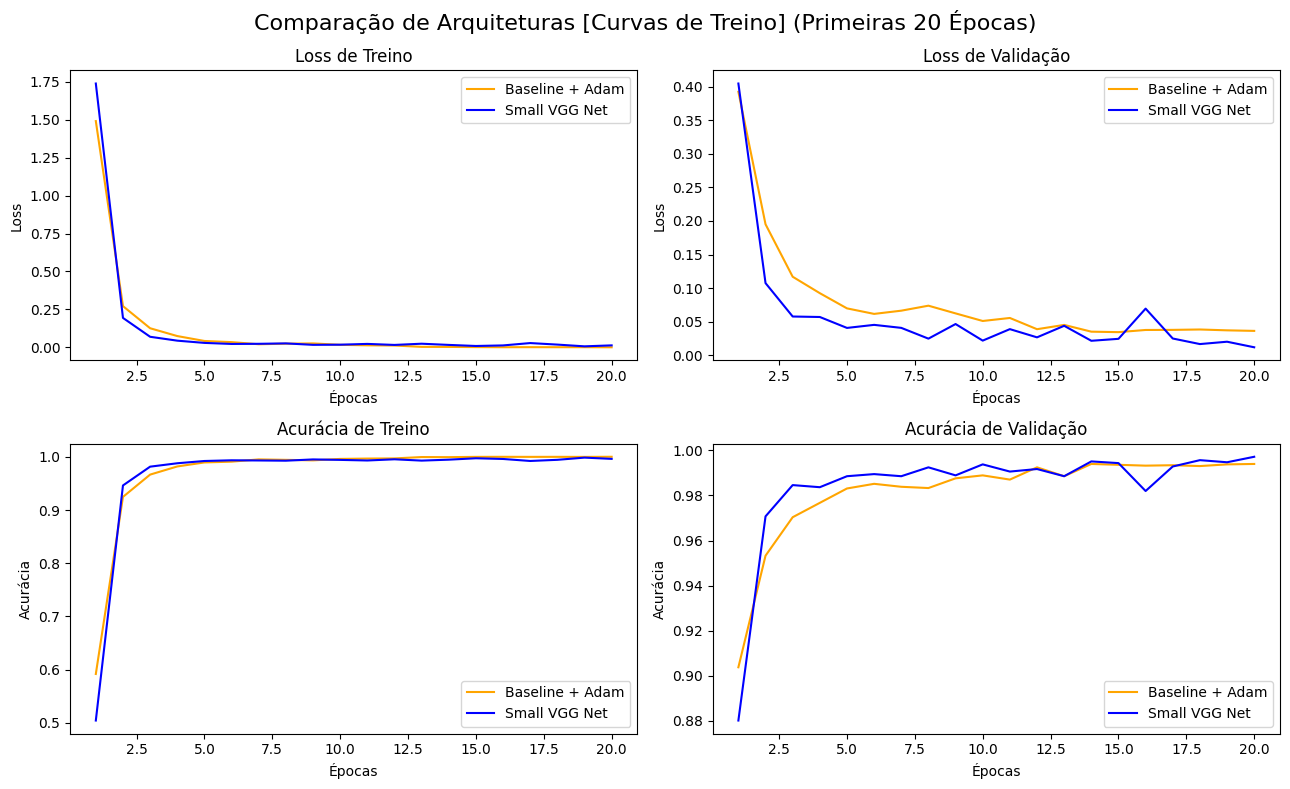

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Find the minimum length among all history lists
min_epochs_length = float('inf')
for name, r in metrics.items():
    if len(r["train_loss"]) < min_epochs_length:
        min_epochs_length = len(r["train_loss"])

epochs = range(1, min_epochs_length + 1)
colors = {'baseline': 'orange', 'vgg': 'blue'}
labels = {'baseline': "Baseline + Adam", 'vgg': 'Small VGG Net'}

for name, r in metrics.items():
    axes[0,0].plot(epochs, r["train_loss"][:min_epochs_length], label=labels[name], color=colors[name])
    axes[0,0].set_title("Loss de Treino")
    axes[0,0].set_xlabel("Épocas")
    axes[0,0].set_ylabel("Loss")
    axes[0,0].legend()

for name, r in metrics.items():
    axes[0,1].plot(epochs, r["val_loss"][:min_epochs_length], label=labels[name], color=colors[name])
    axes[0,1].set_title("Loss de Validação")
    axes[0,1].set_xlabel("Épocas")
    axes[0,1].set_ylabel("Loss")
    axes[0,1].legend()

for name, r in metrics.items():
    axes[1,0].plot(epochs, r["train_acc"][:min_epochs_length], label=labels[name], color=colors[name])
    axes[1,0].set_title("Acurácia de Treino")
    axes[1,0].set_xlabel("Épocas")
    axes[1,0].set_ylabel("Acurácia")
    axes[1,0].legend()

for name, r in metrics.items():
    axes[1,1].plot(epochs, r["val_acc"][:min_epochs_length], label=labels[name], color=colors[name])
    axes[1,1].set_title("Acurácia de Validação")
    axes[1,1].set_xlabel("Épocas")
    axes[1,1].set_ylabel("Acurácia")
    axes[1,1].legend()

plt.suptitle(f"Comparação de Arquiteturas [Curvas de Treino] (Primeiras {min_epochs_length} Épocas)", fontsize=16)
plt.tight_layout()
plt.savefig("figs/exp6-1_curves.png", dpi=150, bbox_inches="tight")
plt.show()